# HybridFactorGraph

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/gtsam/hybrid/doc/HybridFactorGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass  # Not running on Colab, do nothing

`HybridFactorGraph` is a `gtsam.FactorGraph` specifically designed to hold `gtsam.Factor` types that can represent hybrid discrete-continuous systems. While it can store any factor type (like its base class), it provides convenience methods for working with hybrid systems.

It serves as a base class for more specialized hybrid factor graphs:
*   `gtsam.HybridGaussianFactorGraph`: Holds factors that are either Gaussian, discrete, or hybrid Gaussian (linear conditional Gaussians dependent on discrete modes). Result of linearizing a `HybridNonlinearFactorGraph`.
*   `gtsam.HybridNonlinearFactorGraph`: Holds factors that can be nonlinear, discrete, or hybrid nonlinear (nonlinear functions dependent on discrete modes).

This notebook focuses on the base `HybridFactorGraph` interface. See the derived classes for specific elimination and usage examples.

In [2]:
import gtsam
import numpy as np
import graphviz

from gtsam import (
    PriorFactorPose2,
    BetweenFactorPose2,
    Pose2,
    DecisionTreeFactor,
    HybridFactorGraph,
    HybridGaussianFactor,
    JacobianFactor,
)
from gtsam.symbol_shorthand import X, D

## Initialization and Adding Factors

In [3]:
# Create an empty HybridFactorGraph
hfg = HybridFactorGraph()

# --- Create diverse factors ---
# Nonlinear (can be added, but usage depends on derived graph type)
prior_nl = PriorFactorPose2(X(0), Pose2(0,0,0), gtsam.noiseModel.Unit.Create(3))
between_nl = BetweenFactorPose2(X(0), X(1), Pose2(1,0,0), gtsam.noiseModel.Unit.Create(3))

# Discrete
dk1 = (D(0), 2)
dk2 = (D(1), 2)
discrete_f = DecisionTreeFactor([dk1, dk2], "0.1 0.9 0.2 0.8")

# Hybrid Gaussian
dk_h = (D(2), 2) # Hybrid mode key
gf0 = JacobianFactor(X(5), np.eye(1)*2, np.zeros(1), gtsam.noiseModel.Unit.Create(1))
gf1 = JacobianFactor(X(5), np.eye(1)*0.5, np.ones(1), gtsam.noiseModel.Unit.Create(1))
hybrid_gf = HybridGaussianFactor(dk_h, [gf0, gf1])

# Add factors to the graph
hfg.push_back(prior_nl) # Index 0
hfg.push_back(discrete_f) # Index 1
hfg.push_back(hybrid_gf)  # Index 2
# Can also add standard Gaussian factors if needed
gaussian_f = JacobianFactor(X(6), np.eye(1), np.zeros(1), gtsam.noiseModel.Unit.Create(1))
hfg.add(gaussian_f) # Index 3

print(f"HybridFactorGraph size: {hfg.size()}")
hfg.print("\nGraph Contents:")

HybridFactorGraph size: 4

Graph Contents: 
size: 4
factor 0: PriorFactor on x0
  prior mean:  (0, 0, 0)
  noise model: unit (3) 
factor 1:  f[ (d0,2), (d1,2), ]
 Choice(d1) 
 0 Choice(d0) 
 0 0 Leaf  0.1
 0 1 Leaf  0.2
 1 Choice(d0) 
 1 0 Leaf  0.9
 1 1 Leaf  0.8
factor 2: 
Hybrid [x5; d2]{
 Choice(d2) 
 0 Leaf :
  A[x5] = [
	2
]
  b = [ 0 ]
  Noise model: unit (1) 
scalar: 0

 1 Leaf :
  A[x5] = [
	0.5
]
  b = [ 1 ]
  Noise model: unit (1) 
scalar: 0

}
factor 3: 
  A[x6] = [
	1
]
  b = [ 0 ]
  Noise model: unit (1) 


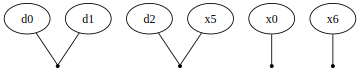

In [4]:
# We can visualize the graph using Graphviz
graphviz.Source(hfg.dot())

## Inspecting Keys

`HybridFactorGraph` provides methods to easily retrieve sets of discrete and continuous keys present in the graph.

In [5]:
discrete_keyset = hfg.discreteKeySet() # Returns gtsam.KeySet
print(f"Discrete KeySet: {discrete_keyset}")

continuous_keyset = hfg.continuousKeySet() # Returns gtsam.KeySet
print(f"Continuous KeySet: {continuous_keyset}")

all_keys = hfg.keys() # Inherited from FactorGraph base class
print(f"All Keys (including nonlinear): {all_keys}")

Discrete KeySet: d0d1d2
Continuous KeySet: x0x5x6
All Keys (including nonlinear): d0d1d2x0x5x6


## Error Calculation

The `error` method sums the errors of all contained factors, assuming appropriate `Values` (or `HybridValues`) are provided. The exact interpretation depends on the factor types (nonlinear error, Gaussian negative log-likelihood, etc.).

In [6]:
# Requires HybridValues to evaluate all factor types
hybrid_values = gtsam.HybridValues()

# Add Nonlinear values
nl_values = gtsam.Values()
nl_values.insert(X(0), Pose2(0.1, 0, 0)) # Small error for prior
nl_values.insert(X(1), Pose2(1.1, 0, 0)) # Matches between factor
hybrid_values.insert(nl_values)

# Add Discrete values
disc_values = gtsam.DiscreteValues()
disc_values[D(0)] = 0
disc_values[D(1)] = 1
disc_values[D(2)] = 0 # Selects gf0 in the hybrid factor
hybrid_values.insert(disc_values)

# Add Continuous Vector values
vec_values = gtsam.VectorValues()
vec_values.insert(X(5), np.array([0.1])) # Value for hybrid_gf (component 0)
vec_values.insert(X(6), np.array([0.2])) # Value for gaussian_f
hybrid_values.insert(vec_values)

print("\nEvaluating error with HybridValues:")
hybrid_values.print()

try:
    total_error = hfg.error(hybrid_values)
    print(f"\nTotal graph error: {total_error}")
    # Note: Error interpretation mixes nonlinear, discrete (-log(prob)), Gaussian
except Exception as e:
    print(f"\nError calculating graph error: {e}")
    print("Ensure HybridValues contains assignments for all keys in all factors.")


Evaluating error with HybridValues:
HybridValues: 
  Continuous: 2 elements
  x5: 0.1
  x6: 0.2
  Discrete: (d0, 0)(d1, 1)(d2, 0)
  Nonlinear
Values with 2 values:
Value x0: (gtsam::Pose2)
(0.1, 0, 0)

Value x1: (gtsam::Pose2)
(1.1, 0, 0)


Total graph error: 0.15036051565782632


## Further Operations

Operations like elimination (`eliminateSequential`, `eliminateMultifrontal`) are typically performed on the more specific derived classes ([`HybridGaussianFactorGraph`](HybridGaussianFactorGraph.ipynb), [`HybridNonlinearFactorGraph`](HybridNonlinearFactorGraph.ipynb)). See their documentation for details.